In [1]:
import pandas as pd
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon, ks_2samp, pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import f_oneway
from scipy.stats import mannwhitneyu
from scipy.stats import anderson_ksamp, PermutationMethod

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.interpolate import interp1d
from scipy.stats import ks_2samp
from scipy.integrate import simpson
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from dtaidistance import dtw
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from scipy.spatial.distance import cosine
from scipy.stats import ttest_rel
from scipy.stats import cramervonmises_2samp

from scipy.stats import wilcoxon
from scipy.stats import anderson_ksamp , PermutationMethod

In [2]:
df = pd.read_excel('C:/Users/yasmi/Downloads/Validation mastere2.xlsx',engine='openpyxl')

In [3]:
def calculate_relative_error(F_exp, F_num):
    F_exp = np.asarray(F_exp)
    F_num = np.asarray(F_num)
    valid_mask = (F_exp != 0) & ~np.isnan(F_exp) & ~np.isnan(F_num)
    F_exp_filtered = F_exp[valid_mask]
    F_num_filtered = F_num[valid_mask]
    if len(F_exp_filtered) == 0:
        return np.nan, 0
    relative_differences = (F_exp_filtered - F_num_filtered) / F_exp_filtered
    m = len(F_exp_filtered)
    error = np.sqrt(np.sum(relative_differences**2)) / m
    return error, m

Temperature = 25°c
R2: 0.8447, MAE: 80.5494, MSE: 7853.5280, RMSE: 88.6201, Pearson correlation: 0.9886, Cosine Similarity: 0.9999 
Relative Error : 0.2019% (computed over 451 points)
Pearson Correlation: 0.9886, p-value: 0.0000


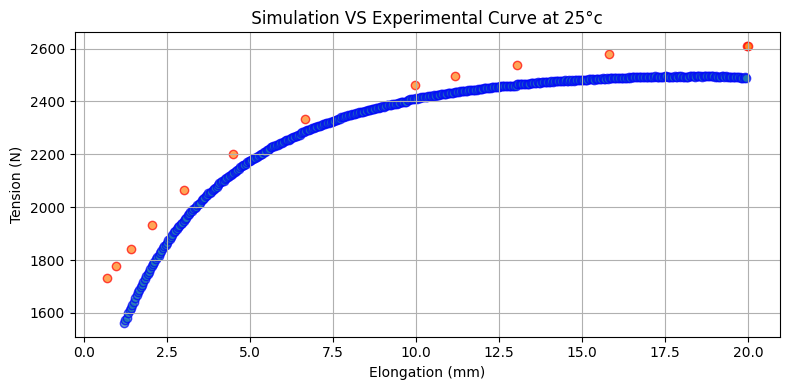

Temperature = 100°c
R2: 0.8857, MAE: 59.9820, MSE: 4416.9738, RMSE: 66.4603, Pearson correlation: 0.9895, Cosine Similarity: 0.9999 
Relative Error : 0.1531% (computed over 455 points)
Pearson Correlation: 0.9895, p-value: 0.0000


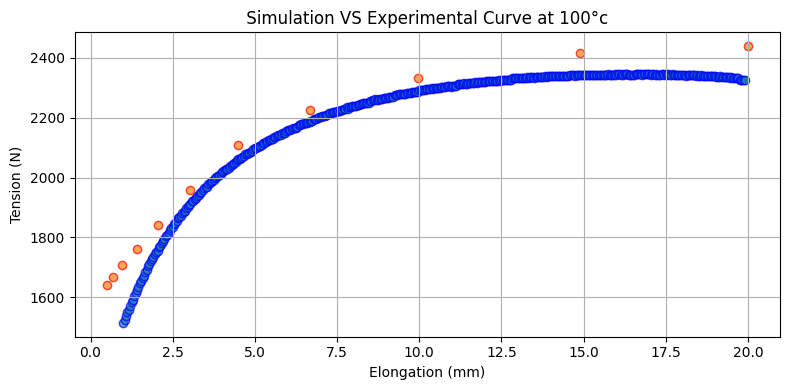

Temperature = 150°c
R2: 0.8670, MAE: 61.4699, MSE: 4378.1981, RMSE: 66.1680, Pearson correlation: 0.9914, Cosine Similarity: 0.9999 
Relative Error : 0.1546% (computed over 439 points)
Pearson Correlation: 0.9914, p-value: 0.0000


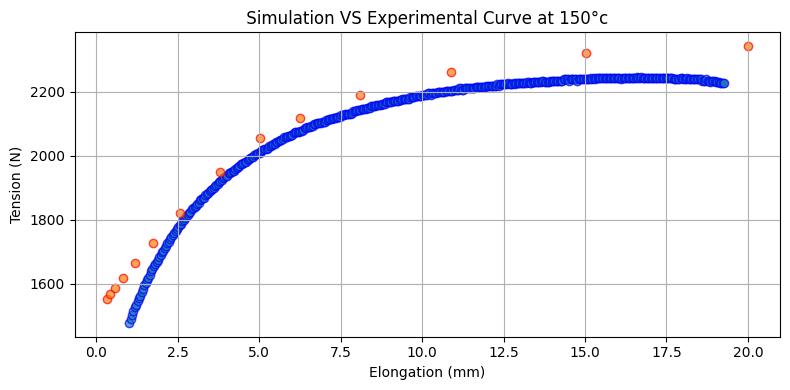

Temperature = 200°c
R2: 0.9564, MAE: 31.3949, MSE: 1571.9229, RMSE: 39.6475, Pearson correlation: 0.9985, Cosine Similarity: 0.9999 
Relative Error : 0.1207% (computed over 376 points)
Pearson Correlation: 0.9985, p-value: 0.0000


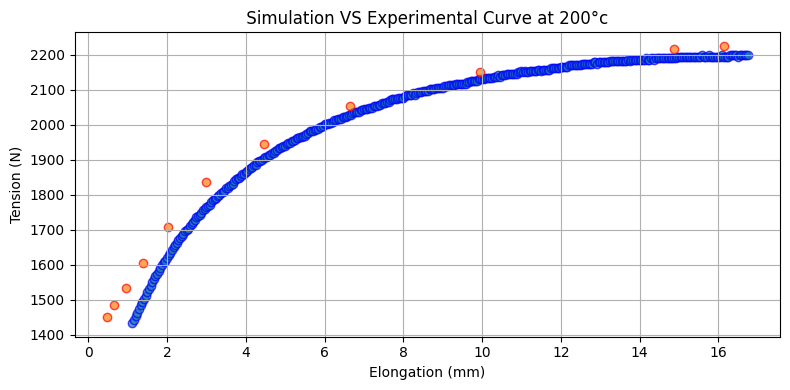

In [4]:
levels = [25, 100, 150, 200]
errors = {}

for lvl in levels:
    
    x_exp = df[f"Dep_E_{lvl}"].dropna()
    y_exp = df[f"Charge_E_{lvl}"].dropna()
    
    x_sim = df[f"Dep_S_{lvl}"].dropna()
    y_sim = df[f"Charge_S_{lvl}"].dropna()
    
    interp_func = interp1d(x_sim, y_sim, kind='linear', bounds_error=False, fill_value="extrapolate") 
    
    y_sim_interp = interp_func(x_exp)

    rmse = np.sqrt(mean_squared_error(y_exp, y_sim_interp))
    mse = mean_squared_error(y_exp, y_sim_interp)
    mae = mean_absolute_error(y_exp, y_sim_interp)
    r2 = r2_score(y_exp, y_sim_interp)
    corr, p_p = pearsonr(y_exp, y_sim_interp)
    cos_sim = cosine_similarity([y_exp], [ y_sim_interp])[0][0]

    err, m = calculate_relative_error(y_exp, y_sim_interp)
    errors[lvl] = (err, m)

    print(f"Temperature = {lvl}°c")

    print(f"R2: {r2:.4f}, MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, Pearson correlation: {corr:.4f}, Cosine Similarity: {cos_sim:.4f} ")
    print(f"Relative Error : {err:.4%} (computed over {m} points)")
    print(f"Pearson Correlation: {corr:.4f}, p-value: {p_p:.4f}")
    
    plt.figure(figsize=(8, 4))
    #plt.plot(x_exp, y_exp, '-', label="Experimental")
    #plt.plot(x_exp, y_sim_interp, '--', label="Simulation (Linear Interpolated)")
    plt.scatter(x_exp, y_exp, alpha=0.7, edgecolors='b')
    plt.scatter(x_sim, y_sim, alpha=0.7, edgecolors='r')
    
    
    plt.xlabel("Elongation (mm)")
    plt.ylabel("Tension (N)")
    plt.title(f" Simulation VS Experimental Curve at {lvl}°c ")
    #plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
results = []


temps = [25, 100, 150, 200]

for temp in temps:

    x_exp = df[f"Dep_E_{temp}"].dropna().values
    y_exp = df[f"Charge_E_{temp}"].dropna().values
    x_sim = df[f"Dep_S_{temp}"].dropna().values
    y_sim = df[f"Charge_S_{temp}"].dropna().values
    charge_e = df[f"Charge_E_{temp}"].dropna().values
    charge_s = df[f"Charge_S_{temp}"].dropna().values
    
    ks_stat, ks_pval = ks_2samp(charge_e, charge_s)

    cr_result = cramervonmises_2samp(charge_e, charge_s)
    cr_stat = cr_result.statistic
    cr_pval = cr_result.pvalue 

    mannwhitney_pval = mannwhitneyu(charge_e, charge_s, alternative='two-sided').pvalue

    try:
        bins = np.histogram_bin_edges(np.concatenate([charge_e, charge_s]), bins='auto')
        obs_e, _ = np.histogram(charge_e, bins=bins)
        obs_s, _ = np.histogram(charge_s, bins=bins)
        contingency = np.array([obs_e, obs_s])
        chi2_stat, chi2_pval, _, _ = chi2_contingency(contingency)
    except Exception as e:
        chi2_pval = np.nan 
        
    try:
        anova_pval = f_oneway(charge_e, charge_s).pvalue
    except Exception:
        anova_pval = np.nan

    try:
        ad_result = anderson_ksamp([charge_e, charge_s], method=PermutationMethod(n_resamples=10000))
        ad_pval = ad_result.significance_level / 100
    except Exception:
        ad_pval = np.nan

    results.append({
        "Temperature (°C)": temp,
        "KS-test p-value": ks_pval,
        "CR-test p-value": cr_pval,
        "Mann–Whitney U p-value" : mannwhitney_pval,
        "ANOVA p-value": anova_pval,
        "AD p-value": ad_pval,

    })

results_df = pd.DataFrame(results)

print(results_df)


   Temperature (°C)  KS-test p-value  CR-test p-value  Mann–Whitney U p-value  \
0                25         0.105163     1.636846e-08                0.991622   
1               100         0.032537     1.059729e-10                0.051734   
2               150         0.018791     2.946232e-11                0.027612   
3               200         0.063381     2.320566e-04                0.056740   

   ANOVA p-value  AD p-value  
0       0.236773    0.000015  
1       0.001513    0.000042  
2       0.000144    0.000005  
3       0.001296    0.000037  


In [6]:
x_exp = df[f"Dep_E_200"].dropna().values
y_exp = df[f"Charge_E_200"].dropna().values
x_sim = df[f"Dep_S_200"].dropna().values
y_sim = df[f"Charge_S_200"].dropna().values

In [7]:
from scipy.stats import ks_2samp

norm_a = y_exp
norm_b = y_sim

sets = [norm_a, norm_b]
names = ['norm_a', 'norm_b']
ks_scores = {}

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        name1, sample1 = names[i], sets[i]
        name2, sample2 = names[j], sets[j]
        key = f"{name1}_{name2}"
        ks_result = ks_2samp(sample1, sample2)
        ks_scores[key] = ks_result

res = ks_scores['norm_a_norm_b']
print(f"norm_a vs norm_b: ks = {res.statistic:.4f} (p-value = {res.pvalue:.3e}, are equal = {res.pvalue > 0.05})")


norm_a vs norm_b: ks = 0.3837 (p-value = 6.338e-02, are equal = True)


In [8]:
from scipy.stats import chisquare
import numpy as np
levels = [25, 100, 150, 200]
for lvl in levels:
    print (lvl)
    x_exp = df[f"Dep_E_{lvl}"].dropna()
    y_exp = df[f"Charge_E_{lvl}"].dropna()
    
    x_sim = df[f"Dep_S_{lvl}"].dropna()
    y_sim = df[f"Charge_S_{lvl}"].dropna()
    
    interp_func = interp1d(x_sim, y_sim, kind='linear', bounds_error=False, fill_value="extrapolate") 
    
    y_sim_interp = interp_func(x_exp)
    
    bins = np.linspace(min(y_exp.min(), y_sim_interp.min()), max(y_exp.max(), y_sim_interp.max()), 10)
    
    exp_hist, _ = np.histogram(y_exp, bins=bins)
    sim_hist, _ = np.histogram(y_sim_interp, bins=bins)

    exp_hist += 1
    sim_hist += 1
    
    chi2_stat, p_value = chisquare(f_obs=sim_hist, f_exp=exp_hist)
    
    print(f"Chi-squared Statistic: {chi2_stat:.4f}, p-value: {p_value:.4f}")

25
Chi-squared Statistic: 1439.0770, p-value: 0.0000
100
Chi-squared Statistic: 167.7578, p-value: 0.0000
150
Chi-squared Statistic: 15701.1110, p-value: 0.0000
200
Chi-squared Statistic: 13.0669, p-value: 0.1096


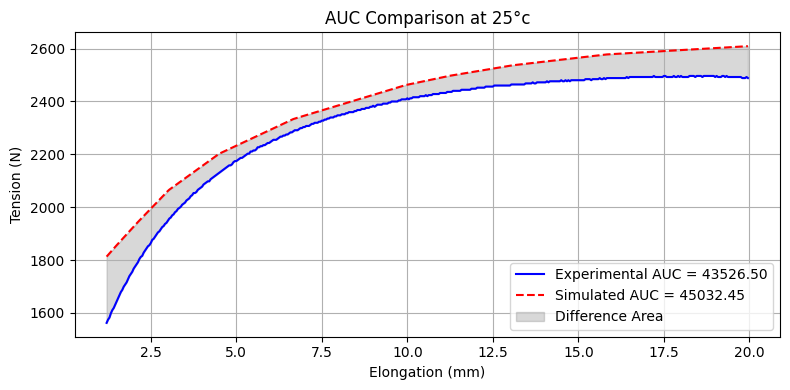

Temperature = 25°c
  Experimental AUC: 43526.50
  Simulated AUC: 45032.45
  Area Between Curves: 1505.91
  Percentage Difference: 3.46%



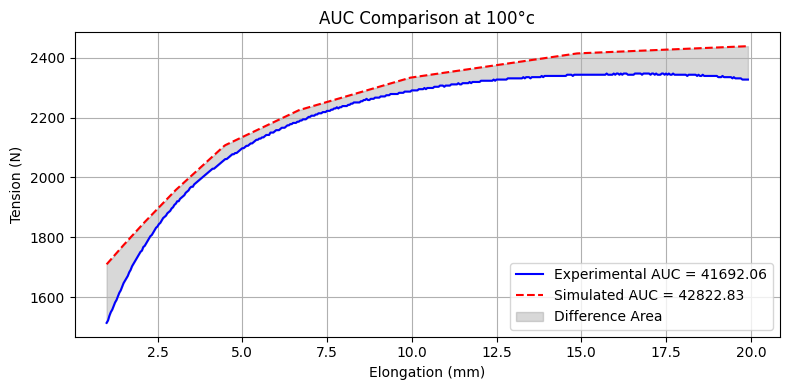

Temperature = 100°c
  Experimental AUC: 41692.06
  Simulated AUC: 42822.83
  Area Between Curves: 1131.29
  Percentage Difference: 2.71%



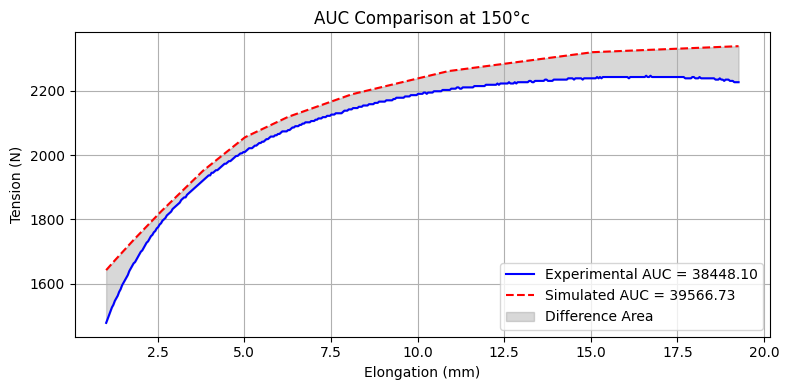

Temperature = 150°c
  Experimental AUC: 38448.10
  Simulated AUC: 39566.73
  Area Between Curves: 1117.98
  Percentage Difference: 2.91%



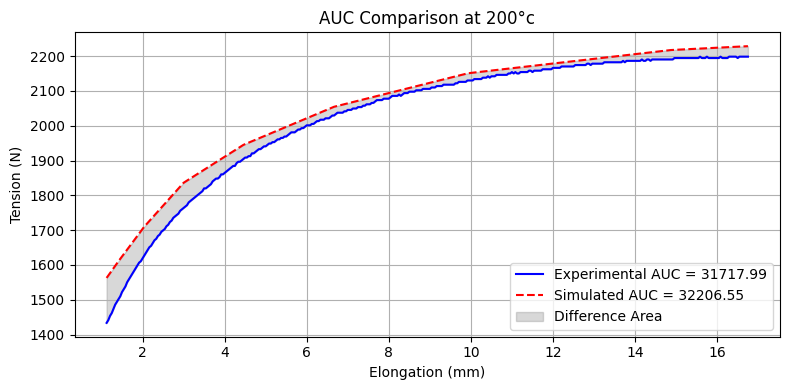

Temperature = 200°c
  Experimental AUC: 31717.99
  Simulated AUC: 32206.55
  Area Between Curves: 488.13
  Percentage Difference: 1.54%



In [9]:
for lvl in levels:
    x_exp = df[f"Dep_E_{lvl}"].dropna().values
    y_exp = df[f"Charge_E_{lvl}"].dropna().values
    x_sim = df[f"Dep_S_{lvl}"].dropna().values
    y_sim = df[f"Charge_S_{lvl}"].dropna().values

    
    interp_func = interp1d(x_sim, y_sim, kind='linear', bounds_error=False, fill_value="extrapolate")
    y_sim_interp = interp_func(x_exp)

    
    auc_exp = np.trapz(y_exp, x=x_exp)
    auc_sim = np.trapz(y_sim_interp, x=x_exp)

    abs_diff = np.abs(y_exp - y_sim_interp)
    area_between_curves = simpson(abs_diff, x_exp)

    auc_diff_percent = abs(auc_exp - auc_sim) / auc_exp * 100

    plt.figure(figsize=(8, 4))
    plt.plot(x_exp, y_exp, label=f'Experimental AUC = {auc_exp:.2f}', color='blue')
    plt.plot(x_exp, y_sim_interp, label=f'Simulated AUC = {auc_sim:.2f}', color='red', linestyle='--')
    plt.fill_between(x_exp, y_exp, y_sim_interp, color='gray', alpha=0.3, label='Difference Area')
    plt.xlabel('Elongation (mm)')
    plt.ylabel('Tension (N)')
    plt.title(f'AUC Comparison at {lvl}°c')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

   
    print(f"Temperature = {lvl}°c")
    print(f"  Experimental AUC: {auc_exp:.2f}")
    print(f"  Simulated AUC: {auc_sim:.2f}")
    print(f"  Area Between Curves: {area_between_curves:.2f}")
    print(f"  Percentage Difference: {auc_diff_percent:.2f}%\n")

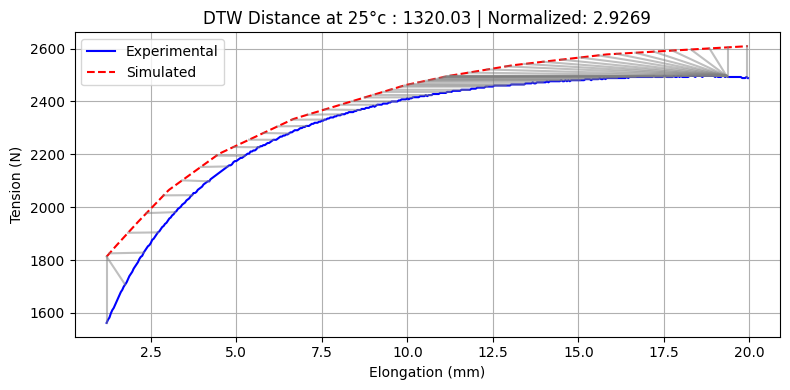

Temperature = 25°c
  DTW Distance: 1320.03
  Normalized DTW Distance: 2.9269



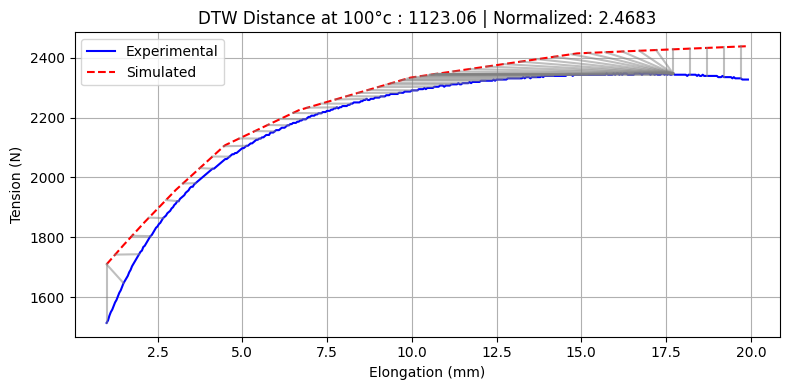

Temperature = 100°c
  DTW Distance: 1123.06
  Normalized DTW Distance: 2.4683



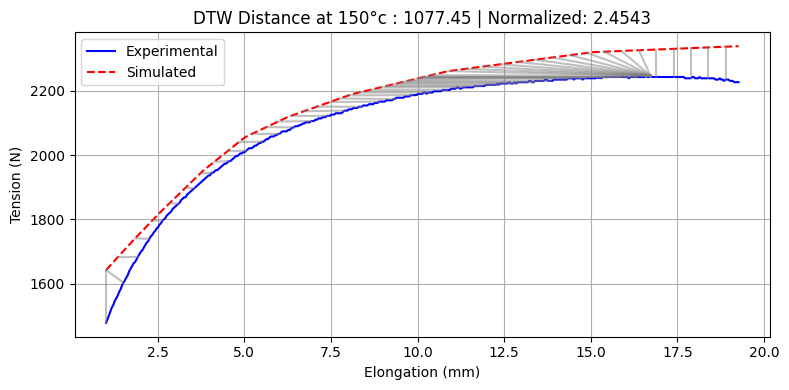

Temperature = 150°c
  DTW Distance: 1077.45
  Normalized DTW Distance: 2.4543



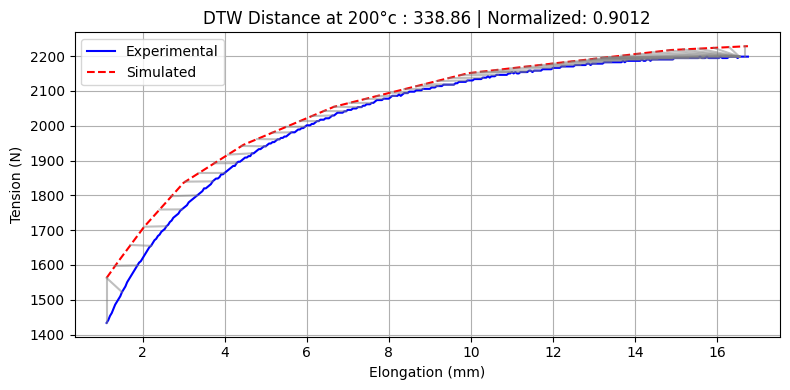

Temperature = 200°c
  DTW Distance: 338.86
  Normalized DTW Distance: 0.9012



In [11]:
for lvl in levels:
    
    x_exp = df[f"Dep_E_{lvl}"].dropna().values
    y_exp = df[f"Charge_E_{lvl}"].dropna().values
    x_sim = df[f"Dep_S_{lvl}"].dropna().values
    y_sim = df[f"Charge_S_{lvl}"].dropna().values

    interp_func = interp1d(x_sim, y_sim, kind='linear', bounds_error=False, fill_value="extrapolate")
    y_sim_interp = interp_func(x_exp)

    # DTW Distance
    dtw_distance = dtw.distance(y_exp , y_sim_interp)
    path = dtw.warping_path(y_exp, y_sim_interp)

    normalized_dtw = dtw_distance / len(y_exp)

    plt.figure(figsize=(8, 4))
    plt.plot(x_exp, y_exp, label='Experimental', color='blue')
    plt.plot(x_exp, y_sim_interp, label='Simulated', color='red', linestyle='--')

    for (i, j) in path[::max(1, int(len(path) / 50))]:  # reduce density
        plt.plot([x_exp[i], x_exp[j]], [y_exp[i], y_sim_interp[j]], color='gray', alpha=0.5)

    plt.title(f'DTW Distance at {lvl}°c : {dtw_distance:.2f} | Normalized: {normalized_dtw:.4f}')
    plt.xlabel('Elongation (mm)')
    plt.ylabel('Tension (N)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Temperature = {lvl}°c")
    print(f"  DTW Distance: {dtw_distance:.2f}")
    print(f"  Normalized DTW Distance: {normalized_dtw:.4f}\n")